<a href="https://colab.research.google.com/github/Roksana18cse04/Ml-project/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models,datasets
import matplotlib.pyplot as plt

In [3]:
#datasets load
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
#pixel value 0-1 normalize
train_images, test_images = train_images / 255.0, test_images / 255.0

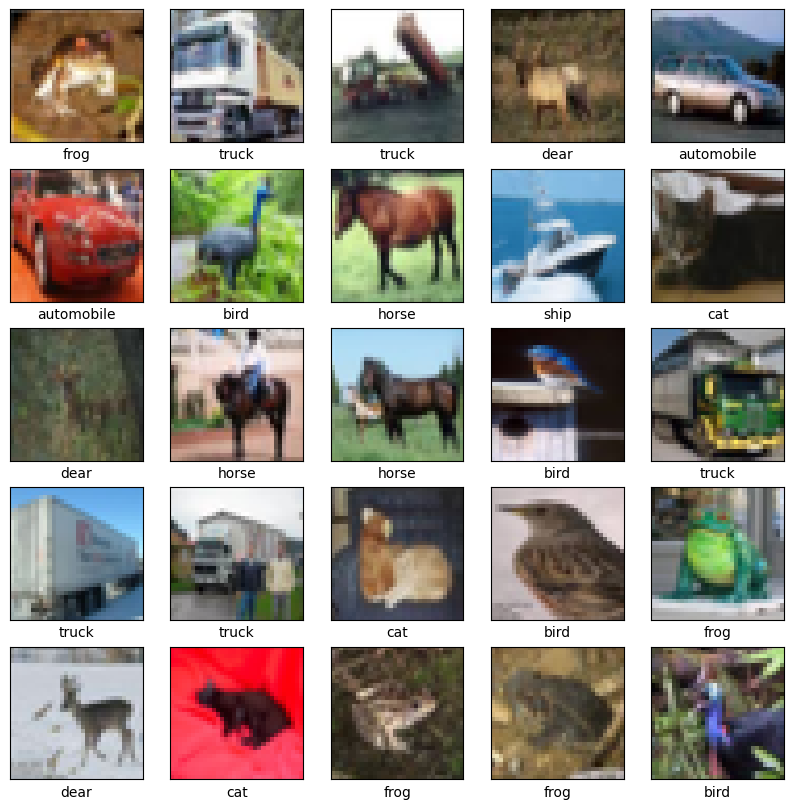

In [5]:
class_names = ['airplane','automobile','bird','cat','dear','dog','frog','horse','ship','truck']
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i],cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [6]:
#create model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

In [9]:
#model train
history = model.fit(train_images,train_labels,epochs=3,validation_data=(test_images,test_labels))
history

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.5996 - loss: 1.1218 - val_accuracy: 0.6315 - val_loss: 1.0399
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.6457 - loss: 0.9989 - val_accuracy: 0.6431 - val_loss: 1.0253
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.6797 - loss: 0.9054 - val_accuracy: 0.6721 - val_loss: 0.9400


In [ ]:
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2)
print(test_acc)

313/313 - 106s - 337ms/step - accuracy: 0.0796 - loss: 2.5692


In [11]:
prediction =model.predict(test_images)

prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


array([[ 4.5715791e-01, -2.6771560e+00,  1.0237107e+00, ...,
         6.5595359e-03,  9.5607656e-01, -2.8678234e+00],
       [ 7.0586700e+00,  9.8709297e+00, -3.7036831e+00, ...,
        -4.2821708e+00,  1.0789000e+01,  6.8769383e+00],
       [ 5.7568240e+00,  4.8888507e+00, -7.2769850e-01, ...,
        -2.5644143e+00,  6.1036549e+00,  2.7728677e+00],
       ...,
       [ 5.5047500e-01, -3.8911548e+00,  3.6611881e+00, ...,
         4.8999057e+00, -9.8529625e-01, -1.9250191e+00],
       [ 2.5080631e+00,  3.8733416e+00, -7.6329879e-02, ...,
        -4.0513027e-01,  1.0520818e+00, -1.5150005e+00],
       [-1.0893039e+00, -4.0722594e+00,  1.9704187e+00, ...,
         8.9418116e+00, -4.3522243e+00, -4.4494109e+00]], dtype=float32)

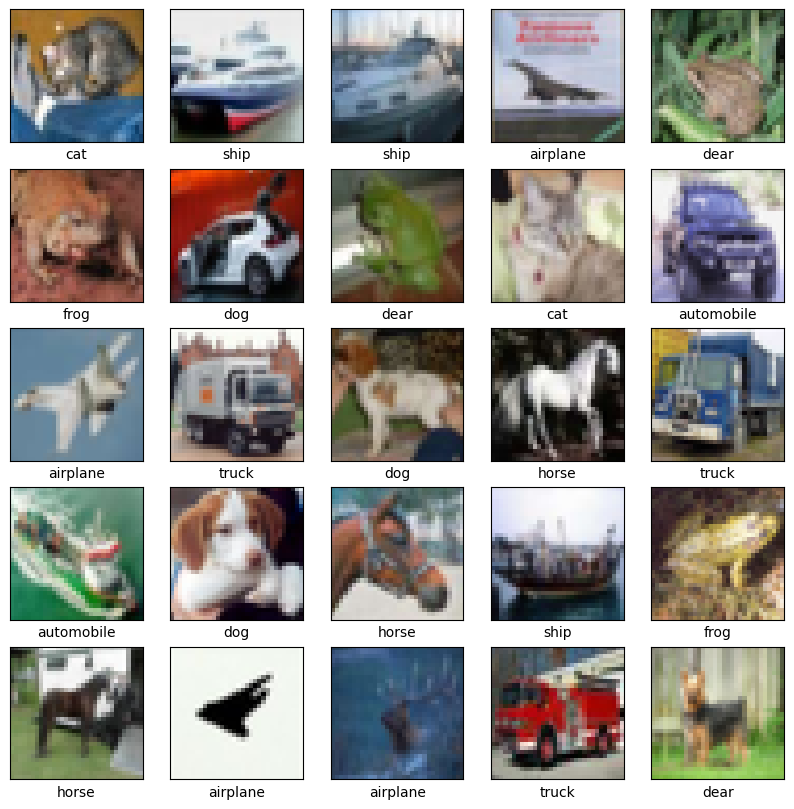

In [12]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i],cmap=plt.cm.binary)
    predicted_lebel = class_names[prediction[i].argmax()]
    true_lbel = class_names[test_labels[i][0]]
    plt.xlabel(class_names[prediction[i].argmax()])
plt.show()

In [14]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen=ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)
datagen.fit(train_images)

In [20]:
history = model.fit(datagen.flow(train_images,train_labels),epochs=30,validation_data=(test_images,test_labels))
history

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 152s 96ms/step - accuracy: 0.2820 - loss: 1.9224 - val_accuracy: 0.4621 - val_loss: 1.5107
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.4394 - loss: 1.5363 - val_accuracy: 0.5610 - val_loss: 1.2050
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 140s 57ms/step - accuracy: 0.5082 - loss: 1.3795 - val_accuracy: 0.6011 - val_loss: 1.1205
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.5393 - loss: 1.2924 - val_accuracy: 0.5975 - val_loss: 1.1309
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.5587 - loss: 1.2428 - val_accuracy: 0.6250 - val_loss: 1.0703
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 60ms/step - accuracy: 0.5781 - loss: 1.1944 - val_accuracy: 0.6440 - val_loss: 1.0028
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 58ms/step - accuracy: 0.5921 - loss: 1.1580 - val_accuracy: 0.6371 - val_loss: 1.0215
Epoch 8/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.6047 - loss: 

In [21]:
from tensorflow.keras.applications import VGG16
vgg_model=VGG16(weights='imagenet',include_top=False,input_shape=(32,32,3))
vgg_model.trainable=False
model=models.Sequential([
    vgg_model,
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10)
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [25]:
prediction = model.predict(test_images)
prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 110s 350ms/step


array([[-1.0016762 , -0.8371607 , -0.93379116, ..., -0.43851572,
         0.8188992 , -0.44059703],
       [-1.0857474 , -1.0518042 , -0.7711363 , ...,  0.01474511,
         0.73214126, -0.31145748],
       [-1.025162  , -1.3850304 , -1.3308308 , ...,  0.22926864,
         0.75270057, -0.5243683 ],
       ...,
       [-1.0284461 , -0.73330176, -1.2603428 , ..., -0.221564  ,
         0.40794933,  0.13722019],
       [-0.9875076 , -0.36396623, -0.8855778 , ..., -0.86533815,
         0.26568037, -0.5553939 ],
       [-1.1990321 , -1.4744277 , -1.3462096 , ...,  0.22636405,
         1.1936337 , -0.5194175 ]], dtype=float32)

In [26]:
predicted_lebel = np.argmax(prediction,axis=1)
predicted_lebel

array([6, 6, 8, ..., 6, 4, 8])

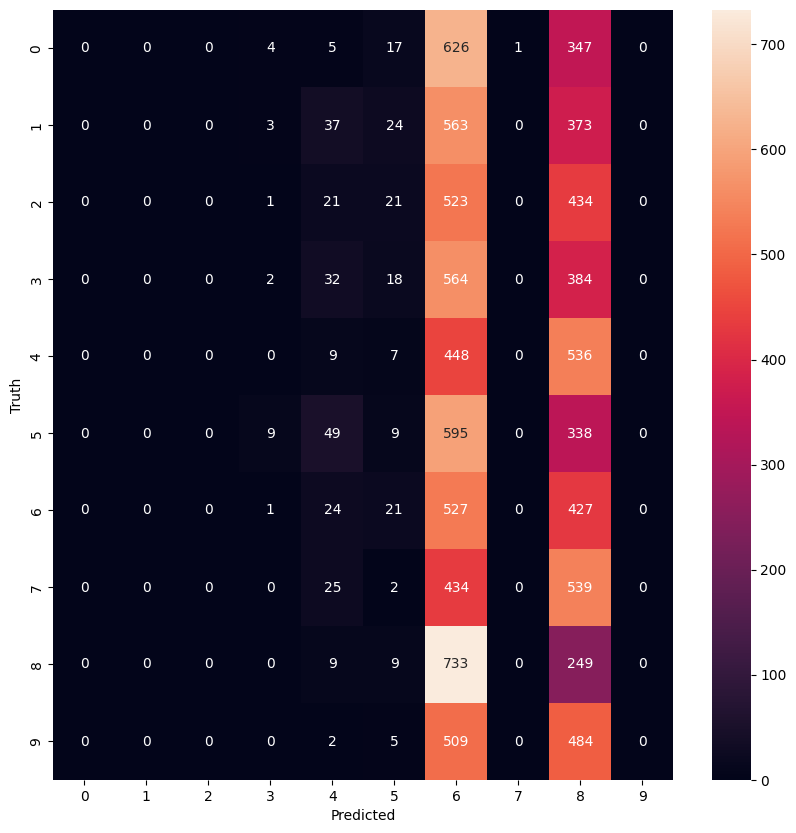

In [27]:
cm=confusion_matrix(test_labels,predicted_lebel)
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [31]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.001),loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

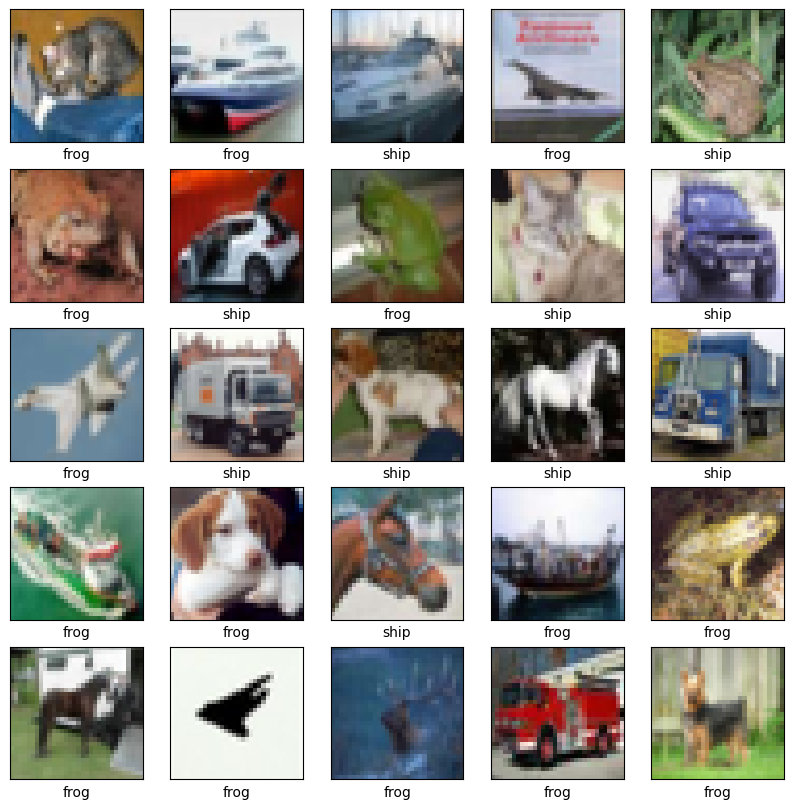

In [32]:
# 5 predict output show
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i],cmap=plt.cm.binary)
    predicted_lebel = class_names[prediction[i].argmax()]
    true_lbel = class_names[test_labels[i][0]]
    plt.xlabel(class_names[prediction[i].argmax()])
plt.show()